# TDA : Clustering des diagrammes de persistance des scans 3D Caesar

#### Paramètres préliminaires

- Packages nécessaires

In [1]:
import utils
import os

np = utils.importer('numpy')
plt = utils.importer('matplotlib.pyplot')
pickle = utils.importer('pickle')
meshio = utils.importer('meshio')

In [2]:
malepath = 'E:/TDA/Male/'
male_scans = os.listdir(malepath)
male_nb_scans = len(male_scans)

In [3]:
girlpath = 'E:/TDA/Female/'
girl_scans = os.listdir(girlpath)
girl_nb_scans = len(girl_scans)

nb_scans = male_nb_scans + girl_nb_scans

- Fonction qui renvoie le nuage de points du scan

In [4]:
def scan_from_index(i):
    if i < male_nb_scans:
        path = malepath + str(male_scans[i])
    else:
        path = girlpath + str(girl_scans[i-male_nb_scans])
    scan = meshio.read(path)
    scan = scan.points
    return scan

- On définit une fonction qui affichent le nuage de points associé à un scan 3D

In [5]:
def plot_scan_3D_interactive(i):
    scan = scan_from_index(i)
    points_set = utils.point_set(scan)
    points_set.plot(color='green', opacity=0.5, size=2)

### Distance entre les diagrammes (Wasserstein)

* On charge les distances, par homologie, précédemment calculées

In [6]:
with open ('./Data/X_Dist_H0.bin', 'rb') as fp:
    dict_dist_0 = pickle.load(fp)
with open ('./Data/X_Dist_H1.bin', 'rb') as fp:
    dict_dist_1 = pickle.load(fp)
with open ('./Data/X_Dist_H2.bin', 'rb') as fp:
    dict_dist_2 = pickle.load(fp)

* On calcule les distances

In [7]:
p = 2
dict_dist = {}
for key in dict_dist_1.keys():
    dict_dist[key] = (dict_dist_0[key]**p+dict_dist_1[key]**p+dict_dist_2[key]**p)**(1/p)

* On choisit le degré d'homologie

In [8]:
d_d = dict_dist

_, distances = zip(*sorted(d_d.items()))

- On affiche les distances maximum et minimum

In [9]:
max_key = max(d_d, key=d_d.get)
min_key = min(d_d, key=d_d.get)

print("max", max_key, d_d[max_key])
print("min", min_key, d_d[min_key])

max (266, 2155) 435.55370341469165
min (2287, 2902) 6.108078565787477


- On affiche les scans 3D des plus distants

In [10]:
plot_scan_3D_interactive(max_key[0])
plot_scan_3D_interactive(max_key[1])

- On affiche les scans 3D des plus proches

In [11]:
plot_scan_3D_interactive(min_key[0])
plot_scan_3D_interactive(min_key[1])

### Clustering hiérarchique complete

In [12]:
dendrogram, linkage, fcluster = utils.importer(
    'scipy.cluster.hierarchy', 'dendrogram', 'linkage', 'fcluster')

plt.rcParams["figure.figsize"] = [15, 10]
plt.rcParams["figure.autolayout"] = True

In [13]:
Z = linkage(distances, metric='precomputed', method='complete')

- Voici le dendrogramme du clustering

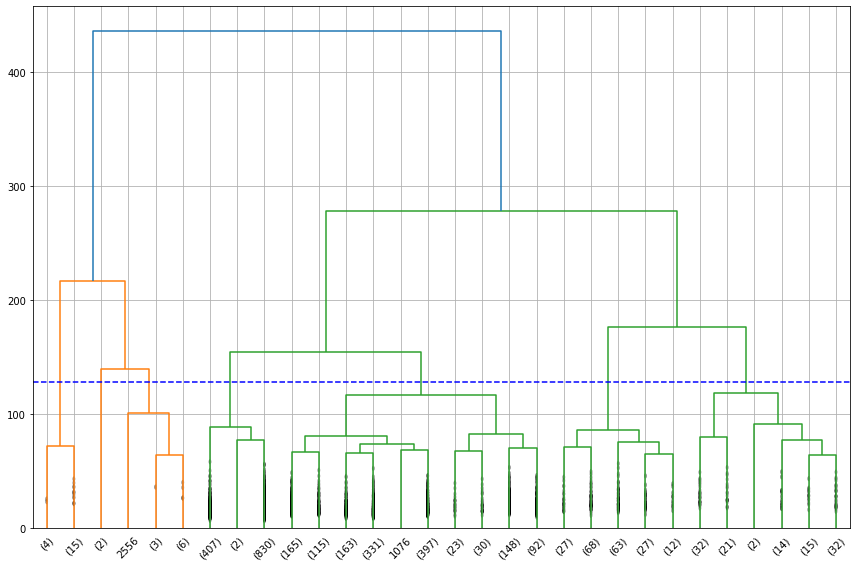

In [14]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
# pour le nb d'individus par branche : show_contracted=True
dendrogram(Z, ax=ax, truncate_mode='lastp', show_contracted=True)
plt.grid(True)
plt.plot([0, 300], [128, 128], 'b--')
plt.tight_layout()
plt.savefig('E:/Projet-M2/2021-m2-ditex-morphotypes/Images/MFDENDCOMPLETE.jpg', dpi=200);

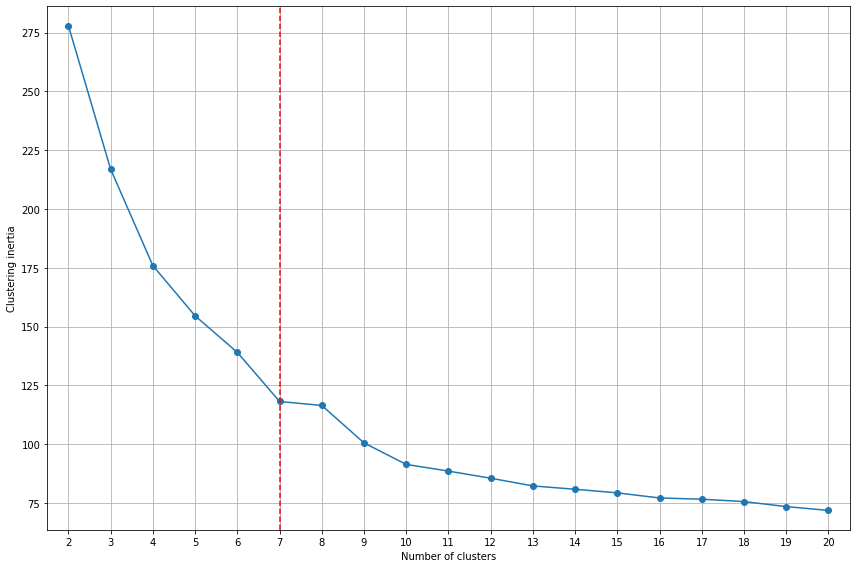

In [15]:
temp = 20  # nombre de clusters à afficher

fig = plt.figure(figsize=(12, 8))
ymin, ymax = np.min(Z[::-1, 2][1:temp]), np.max(Z[::-1, 2][1:temp])
a = (ymax - ymin) / 25

plt.plot(range(2, temp+1), Z[::-1, 2][1:temp], 'o-')
plt.plot([7, 7], [ymin-a, ymax+a], 'r--')
plt.ylim(ymin-a, ymax+a)
plt.xticks(range(2, 21, 1))
plt.xlim(1.5, 20.5)
plt.xlabel('Number of clusters')
plt.ylabel('Clustering inertia')
plt.tight_layout()
plt.grid(True)
plt.savefig('E:/Projet-M2/2021-m2-ditex-morphotypes/Images/MFCElbow.jpg');

- GDI

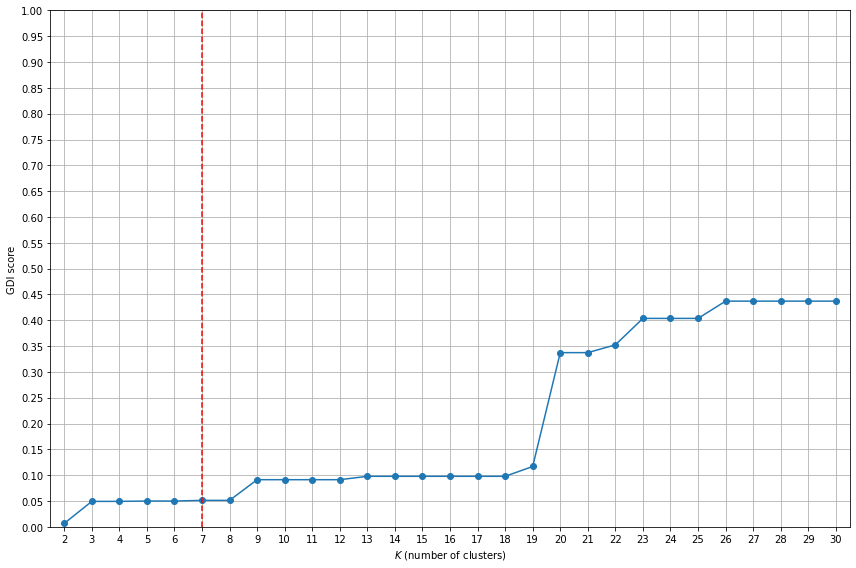

In [16]:
GDI_list = []
borne_nb_clus = 30

for nb_clus in range(2, borne_nb_clus+1):
    clusters = fcluster(Z, nb_clus, criterion='maxclust')
    clusters = clusters.tolist()

    dict_clusters = {}
    for i in range(1, nb_clus+1):
        dict_clusters[i] = []
    for i in range(len(clusters)):
        dict_clusters[clusters[i]].append(i)
    test = 0
    for key in dict_clusters:
        male_percentage = np.sum(
            np.array(dict_clusters[key]) < male_nb_scans) / len(dict_clusters[key])
        test += 2*abs(male_percentage-0.5)*len(dict_clusters[key])
    test /= nb_scans
    GDI_list.append(test)

plt.figure(figsize=(12, 8))
plt.plot(range(2, borne_nb_clus+1), GDI_list, 'o-')
plt.plot([7, 7], [0, 1], 'r--')
plt.ylim(0, 1)
plt.xticks(range(2, 31, 1))
plt.yticks(np.arange(0, 1.05, 0.05))
plt.xlim(1.5, 30.5)
plt.xlabel(r'$K$ (number of clusters)')
plt.ylabel(r'GDI score')
plt.grid(True)
plt.tight_layout()
plt.savefig('E:/Projet-M2/2021-m2-ditex-morphotypes/Images/MFCGDI.jpg');

In [17]:
GDI = [GDI_list.copy()]

- On choisit le nombre de clusters

In [18]:
nb_clus = 7  # À choisir
clusters = fcluster(Z, nb_clus, criterion='maxclust')

- Voici les proportions par cluster

In [19]:
dict_clusters = {}
for i in range(1, nb_clus+1):
    dict_clusters[i] = []
for i in range(len(clusters)):
    dict_clusters[clusters[i]].append(i)

test = 0
for key in dict_clusters:
    male_percentage = np.sum(
        np.array(dict_clusters[key]) < male_nb_scans) / len(dict_clusters[key])
    print('Cluster n°' + str(key), "de taille", len(dict_clusters[key]), 'et ses proportions : Hommes ' + '%.2f' % (
        100*male_percentage), '%, Femmes ' + '%.2f' % (100*(1-male_percentage)), '%\n')

Cluster n°1 de taille 19 et ses proportions : Hommes 21.05 %, Femmes 78.95 %

Cluster n°2 de taille 2 et ses proportions : Hommes 100.00 %, Femmes 0.00 %

Cluster n°3 de taille 10 et ses proportions : Hommes 10.00 %, Femmes 90.00 %

Cluster n°4 de taille 1239 et ses proportions : Hommes 51.57 %, Femmes 48.43 %

Cluster n°5 de taille 1465 et ses proportions : Hommes 50.99 %, Femmes 49.01 %

Cluster n°6 de taille 197 et ses proportions : Hommes 50.25 %, Femmes 49.75 %

Cluster n°7 de taille 116 et ses proportions : Hommes 21.55 %, Femmes 78.45 %



### Clustering hiérarchique Ward

In [20]:
Z = linkage(distances, metric='precomputed', method='ward')

- Voici le dendrogramme du clustering

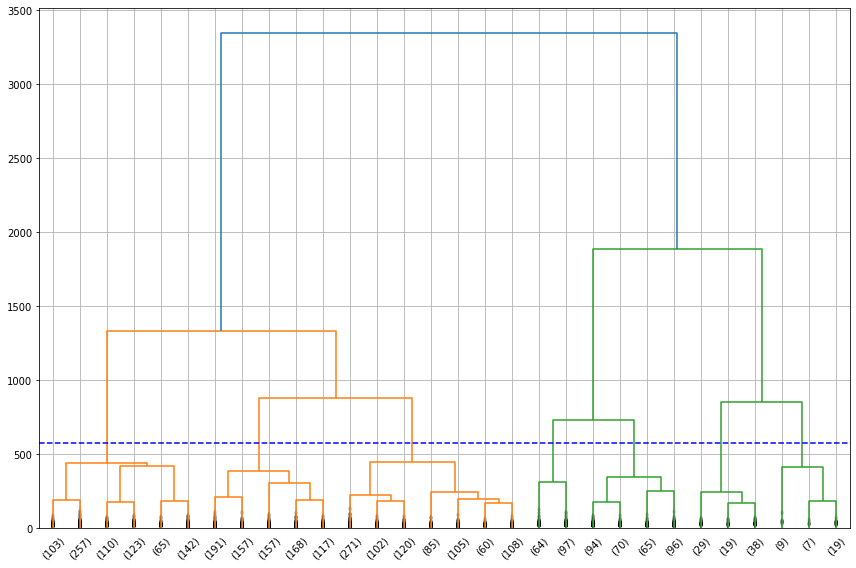

In [21]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
# pour le nb d'individus par branche : show_contracted=True
dendrogram(Z, ax=ax, truncate_mode='lastp', show_contracted=True)
plt.grid(True)
plt.plot([0, 300], [570, 570], 'b--')
plt.tight_layout()
plt.savefig('E:/Projet-M2/2021-m2-ditex-morphotypes/Images/MFDENDWARD.jpg');

### Courbe elbow du clustering

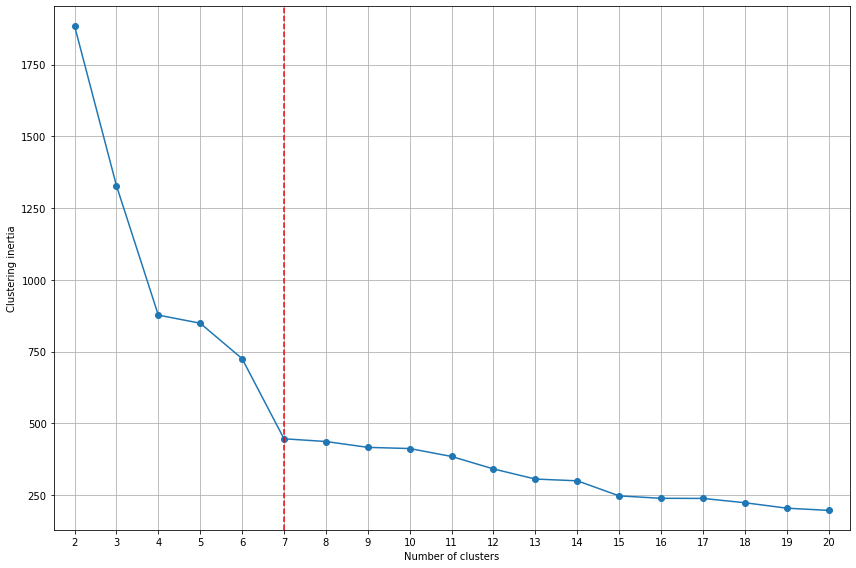

In [22]:
temp = 20  # nombre de clusters à afficher

fig = plt.figure(figsize=(12, 8))
ymin, ymax = np.min(Z[::-1, 2][1:temp]), np.max(Z[::-1, 2][1:temp])
a = (ymax - ymin) / 25

plt.plot(range(2, temp+1), Z[::-1, 2][1:temp], 'o-')
plt.plot([7, 7], [ymin-a, ymax+a], 'r--')
plt.ylim(ymin-a, ymax+a)
plt.xticks(range(2, 21, 1))
plt.xlim(1.5, 20.5)
plt.xlabel('Number of clusters')
plt.ylabel('Clustering inertia')
plt.tight_layout()
plt.grid(True)
plt.savefig('E:/Projet-M2/2021-m2-ditex-morphotypes/Images/MFWElbow.jpg');

- Voici la courbe associée à l'indice de discrimination quand on fait varier le nombre de clusters

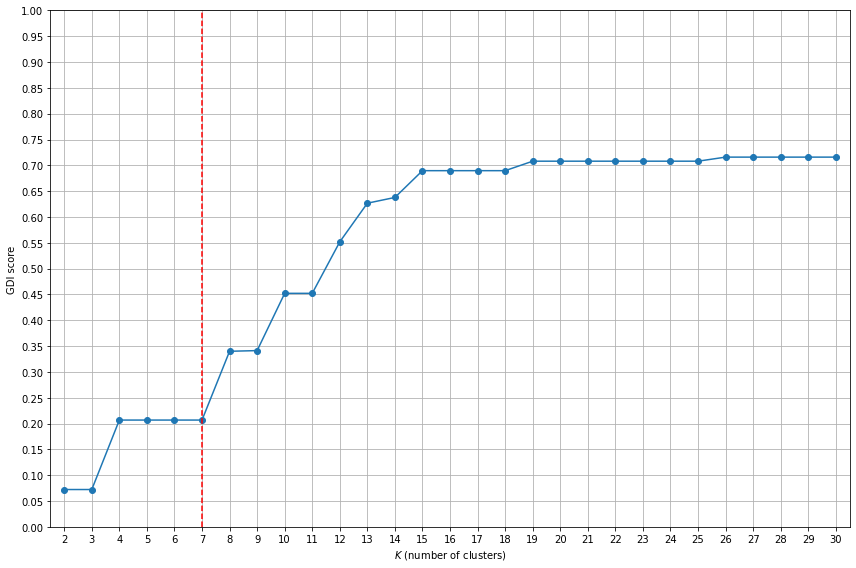

In [23]:
GDI_list = []
borne_nb_clus = 30

for nb_clus in range(2, borne_nb_clus+1):
    clusters = fcluster(Z, nb_clus, criterion='maxclust')
    clusters = clusters.tolist()

    dict_clusters = {}
    for i in range(1, nb_clus+1):
        dict_clusters[i] = []
    for i in range(len(clusters)):
        dict_clusters[clusters[i]].append(i)
    test = 0
    for key in dict_clusters:
        male_percentage = np.sum(
            np.array(dict_clusters[key]) < male_nb_scans) / len(dict_clusters[key])
        test += 2*abs(male_percentage-0.5)*len(dict_clusters[key])
    test /= nb_scans
    GDI_list.append(test)

plt.figure(figsize=(12, 8))
plt.plot(range(2, borne_nb_clus+1), GDI_list, 'o-')
plt.plot([7, 7], [0, 1], 'r--')
plt.ylim(0, 1)
plt.xticks(range(2, 31, 1))
plt.xlim(1.5, 30.5)
plt.yticks(np.arange(0, 1.05, 0.05))
plt.xlabel(r'$K$ (number of clusters)')
plt.ylabel(r'GDI score')
plt.grid(True)
plt.savefig('E:/Projet-M2/2021-m2-ditex-morphotypes/Images/MFWGDI.jpg');

In [24]:
GDI.append(GDI_list.copy())

- On choisit le nombre de clusters pour le clustering

In [25]:
nb_clus = 7  # À choisir
clusters = fcluster(Z, nb_clus, criterion='maxclust')

- Voici les proportions par cluster

In [26]:
dict_clusters = {}
for i in range(1, nb_clus+1):
    dict_clusters[i] = []
for i in range(len(clusters)):
    dict_clusters[clusters[i]].append(i)

test = 0
for key in dict_clusters:
    male_percentage = np.sum(
        np.array(dict_clusters[key]) < male_nb_scans) / len(dict_clusters[key])
    print('Cluster n°' + str(key), "de taille", len(dict_clusters[key]), 'et ses proportions : Hommes ' + '%.2f' % (
        100*male_percentage), '%, Femmes ' + '%.2f' % (100*(1-male_percentage)), '%\n')

Cluster n°1 de taille 800 et ses proportions : Hommes 69.25 %, Femmes 30.75 %

Cluster n°2 de taille 790 et ses proportions : Hommes 41.27 %, Femmes 58.73 %

Cluster n°3 de taille 851 et ses proportions : Hommes 46.06 %, Femmes 53.94 %

Cluster n°4 de taille 161 et ses proportions : Hommes 48.45 %, Femmes 51.55 %

Cluster n°5 de taille 325 et ses proportions : Hommes 43.08 %, Femmes 56.92 %

Cluster n°6 de taille 86 et ses proportions : Hommes 23.26 %, Femmes 76.74 %

Cluster n°7 de taille 35 et ses proportions : Hommes 20.00 %, Femmes 80.00 %



### Centre des clusters

In [27]:
# for i in dict_clusters:
#     medoid = utils.cluster_medoid(dict_clusters[i], d_d)
#     print("Le cluster", i, "est de longueur", str(len(
#         dict_clusters[i]))+", son médoïde est l'individu", medoid, "et voici son scan")
#     plot_scan_3D_interactive(medoid)

## K-Medoids (PAM)

In [28]:
KMedoids = utils.importer('sklearn_extra.cluster', 'KMedoids')
distance = np.zeros((nb_scans, nb_scans))

for i in range(nb_scans):
    for j in range(i+1, nb_scans):
        distance[i, j] = distance[j, i] = d_d[(i, j)]

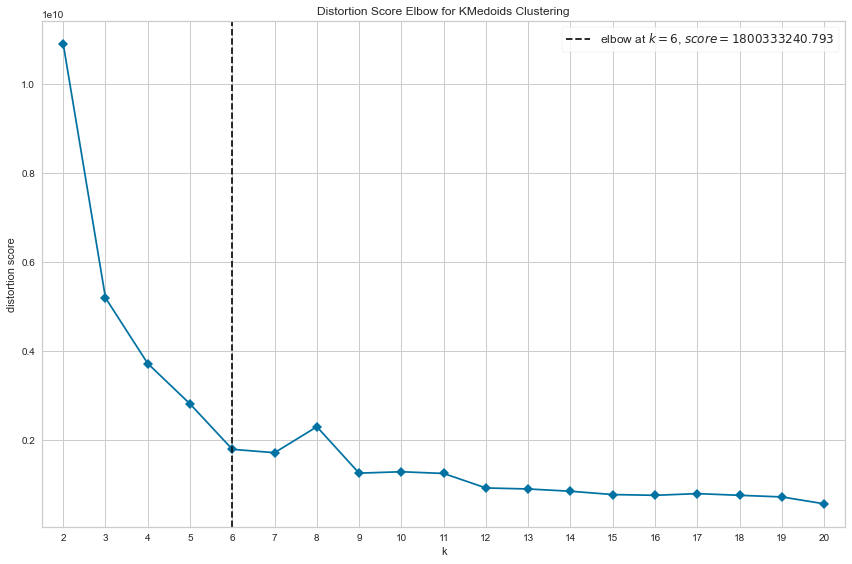

In [29]:
KElbowVisualizer = utils.importer('yellowbrick.cluster', 'KElbowVisualizer')

model = KMedoids(method='pam', metric='precomputed', init='k-medoids++', random_state=42)
visualizer = KElbowVisualizer(model, k=(2, 21), timings=False)

plt.figure(figsize=(12, 8))
visualizer.fit(distance)
plt.xticks(range(2, 21, 1))
plt.xlim(1.5, 20.5)
plt.tight_layout()
visualizer.show();

- Voici la courbe associée à l'indice de discrimination quand on fait varier le nombre de clusters

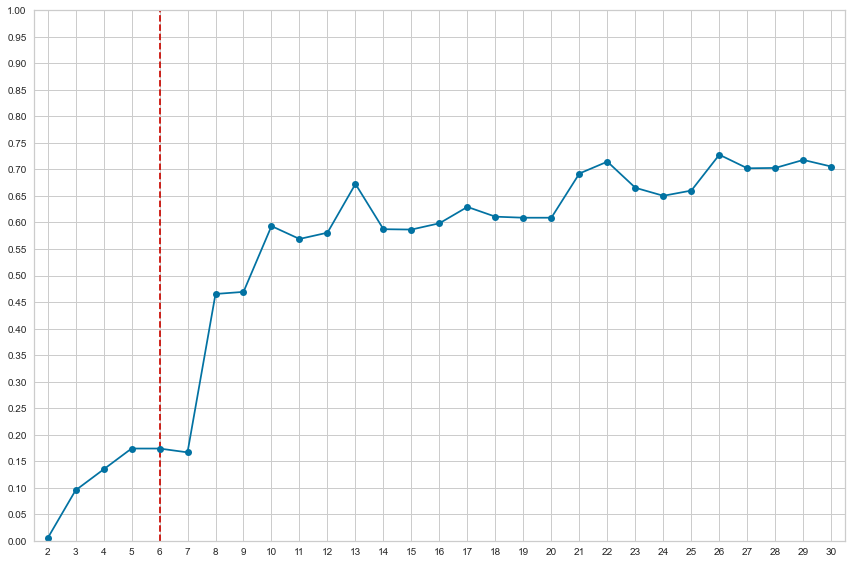

In [30]:
GDI_list = []
borne_nb_clus = 30

for nb_clus in range(2, borne_nb_clus+1):
    kmed = KMedoids(n_clusters=nb_clus, method='pam', metric='precomputed',
                    init='k-medoids++', random_state=42).fit(distance)
    clusters = kmed.labels_

    dict_clusters = {}
    for j in range(nb_clus):
        dict_clusters[j] = []
    for j in range(len(clusters)):
        dict_clusters[clusters[j]].append(j)
    test = 0
    for key in dict_clusters:
        male_percentage = np.sum(
            np.array(dict_clusters[key]) < male_nb_scans) / len(dict_clusters[key])
        test += 2*abs(male_percentage-0.5)*len(dict_clusters[key])
    test /= nb_scans
    GDI_list.append(test)

fig = plt.figure(figsize=(12, 8))
plt.xlim(1.5, 30.5)
plt.xticks(np.arange(2, 31, 1))
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.05, 0.05))
plt.plot([6, 6], [0, 1], 'r--')
plt.plot(range(2, borne_nb_clus+1), GDI_list, 'o-')
plt.grid(True);

In [31]:
nb_clus = 6

kmed = KMedoids(n_clusters=nb_clus, metric='precomputed',
                    init='k-medoids++', method='pam').fit(distance)
clusters = kmed.labels_

In [32]:
dict_clusters = {}
for i in range(1, nb_clus+1):
    dict_clusters[i] = []
for i in range(len(clusters)):
    dict_clusters[clusters[i]+1].append(i)

for key in dict_clusters:
    male_percentage = np.sum(
        np.array(dict_clusters[key]) < male_nb_scans) / len(dict_clusters[key])
    print('Cluster n°' + str(key), "de taille", len(dict_clusters[key]), 'et ses proportions : Hommes ' + '%.2f' % (
        100*male_percentage), '%, Femmes ' + '%.2f' % (100*(1-male_percentage)), '%\n')

Cluster n°1 de taille 431 et ses proportions : Hommes 58.00 %, Femmes 42.00 %

Cluster n°2 de taille 633 et ses proportions : Hommes 46.45 %, Femmes 53.55 %

Cluster n°3 de taille 214 et ses proportions : Hommes 37.85 %, Femmes 62.15 %

Cluster n°4 de taille 98 et ses proportions : Hommes 23.47 %, Femmes 76.53 %

Cluster n°5 de taille 910 et ses proportions : Hommes 44.73 %, Femmes 55.27 %

Cluster n°6 de taille 762 et ses proportions : Hommes 60.63 %, Femmes 39.37 %



In [33]:
GDI.append(GDI_list.copy())

with open('./Data/Wasserstein.bin', 'wb') as fp:
    pickle.dump(GDI, fp)

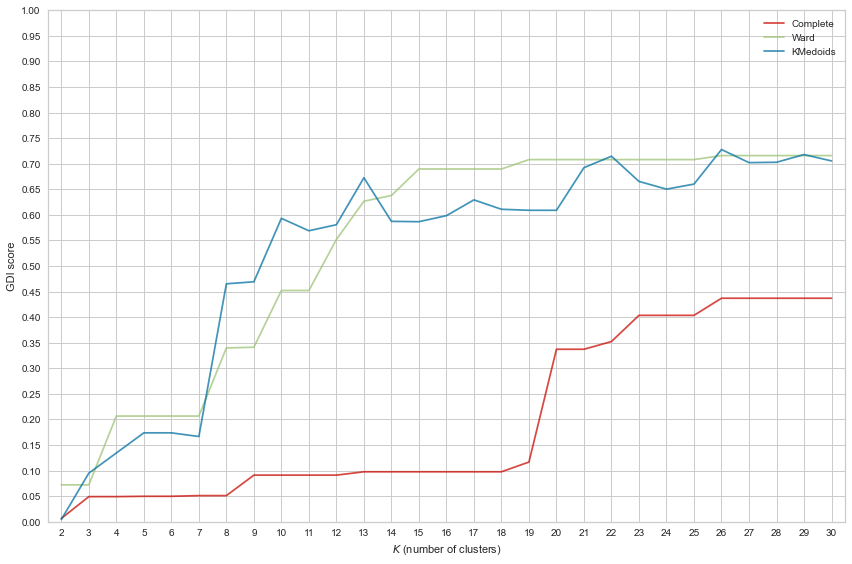

In [34]:
plt.figure(figsize=(12, 8))
plt.plot(range(2, borne_nb_clus+1), GDI[0], 'r', alpha=0.75, label='Complete')
plt.plot(range(2, borne_nb_clus+1), GDI[1], 'g', alpha=0.75, label='Ward')
plt.plot(range(2, borne_nb_clus+1), GDI[2], 'b', alpha=0.75, label='KMedoids')
plt.ylim(0, 1)
plt.xticks(range(2, 31, 1))
plt.xlim(1.5, 30.5)
plt.yticks(np.arange(0, 1.05, 0.05))
plt.xlabel(r'$K$ (number of clusters)')
plt.ylabel(r'GDI score')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('E:/Projet-M2/2021-m2-ditex-morphotypes/Images/MFGDI.jpg', dpi=200);

In [35]:
# indices = kmed.medoid_indices_

# for i in range(indices.shape[0]):
#     medoid = indices[i]
#     print("Le cluster", i+1, "est de longueur", str(len(
#         dict_clusters[i+1]))+", son médoïde est l'individu", medoid, "et voici son scan")
#     plot_scan_3D_interactive(medoid)